In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Final_data.csv')
df.head()
df['order_date'] = pd.to_datetime(df['order_date'])

df['month'] = df['order_date'].dt.month
df.info()
df.describe()

df.tail(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   nama           400 non-null    object        
 1   order_date     400 non-null    datetime64[ns]
 2   required_date  400 non-null    object        
 3   shipped_date   400 non-null    object        
 4   store_name     400 non-null    object        
 5   staff_name     400 non-null    object        
 6   product_name   400 non-null    object        
 7   model_year     400 non-null    int64         
 8   category_name  400 non-null    object        
 9   brand_name     400 non-null    object        
 10  quantity       400 non-null    int64         
 11  list_price     400 non-null    float64       
 12  discount       400 non-null    float64       
 13  total          400 non-null    float64       
 14  month          400 non-null    int32         
dtypes: datetime64[ns](1), f

,nama,order_date,required_date,shipped_date,store_name,staff_name,product_name,model_year,category_name,brand_name,quantity,list_price,discount,total,month
395,Paul Lester,2017-03-27,2017-03-28,2017-03-29,Santa Cruz Bikes,Genna Serrano,Trek X-Caliber 8 - 2017,2017,Mountain Bikes,Trek,2,999.99,0.07,1859.98,3
396,Paul Lester,2017-03-27,2017-03-28,2017-03-29,Santa Cruz Bikes,Genna Serrano,Trek Madone 9.2 - 2017,2017,Road Bikes,Trek,2,4999.99,0.07,9299.98,3
397,Eliana Reese,2017-05-23,2017-05-26,2017-05-24,Baldwin Bikes,Marcelene Boyer,Sun Bicycles Revolutions 24 - Girl's - 2017,2017,Cruisers Bicycles,Sun Bicycles,1,250.99,0.10,225.89,5
398,Eliana Reese,2017-05-23,2017-05-26,2017-05-24,Baldwin Bikes,Marcelene Boyer,Trek Boone 7 - 2017,2017,Cyclocross Bicycles,Trek,2,3499.99,0.05,6649.98,5
399,Gabriel Wagner,2016-02-12,2016-02-15,2016-02-14,Baldwin Bikes,Venita Daniel,Electra Girl's Hawaii 1 (16-inch) - 2015/2016,2016,Children Bicycles,Electra,1,269.99,0.07,251.09,2


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans




df_final = pd.get_dummies(df, columns=['category_name', 'brand_name'], drop_first=True)


X = df_final.drop(columns=['quantity', 'nama', 'order_date', 'required_date', 
                           'shipped_date', 'store_name', 'staff_name', 
                           'product_name', 'total'])
y = df_final['quantity']


x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

print(f"Jumlah fitur yang digunakan: {X.shape[1]}")
print(f"Prediksi pertama: {y_pred[0]}")


Jumlah fitur yang digunakan: 17
Prediksi pertama: 1.320833333333333


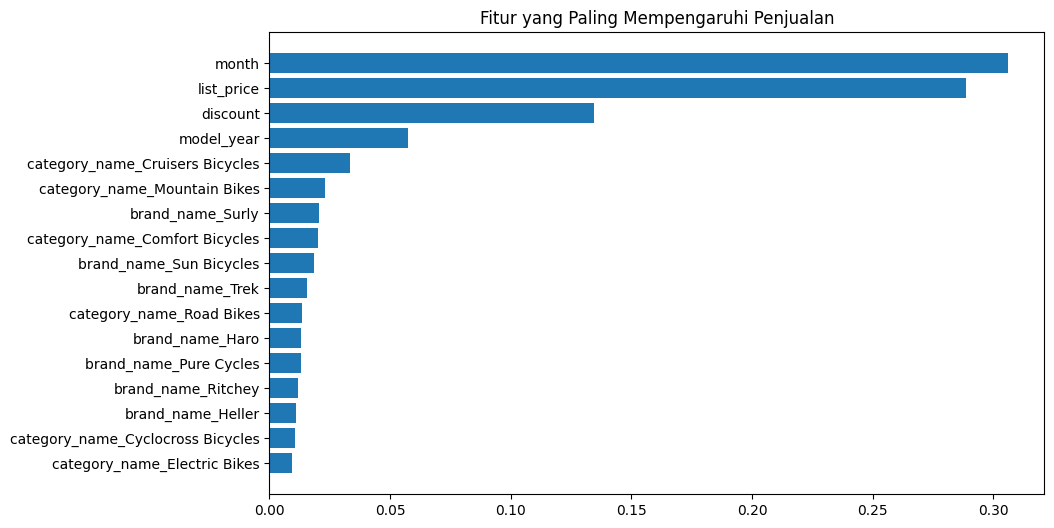

In [ ]:
importances = rf.feature_importances_
feature_names = x_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title('Fitur yang Paling Mempengaruhi Penjualan')
plt.show()


RFM + Segment Data:
                Recency  Monetary  Frequency  Segment
nama                                                 
Abby Gamble        3009   5599.98          1        2
Addie Hahn         2938   1439.98          1        2
Adriene Rivera     3637   5509.98          1        0
Afton Juarez       3509   1079.98          1        0
Aimee Merritt      3235   1499.38          1        2
...                 ...       ...        ...      ...
Yan Mcgowan        3308    438.02          1        2
Yan Trevino        3047    712.49          1        2
Yuk Vega           2916   3608.10          1        2
Zelma Browning     3323    390.58          1        2
Zoraida Patton     3331   4639.98          1        2

[301 rows x 4 columns]

Mean values per segment:
             Recency     Monetary  Frequency
Segment                                     
0        3550.474747  1469.737273   1.000000
1        3352.882353  4389.284353   2.129412
2        3111.615385  1702.928803   1.025641


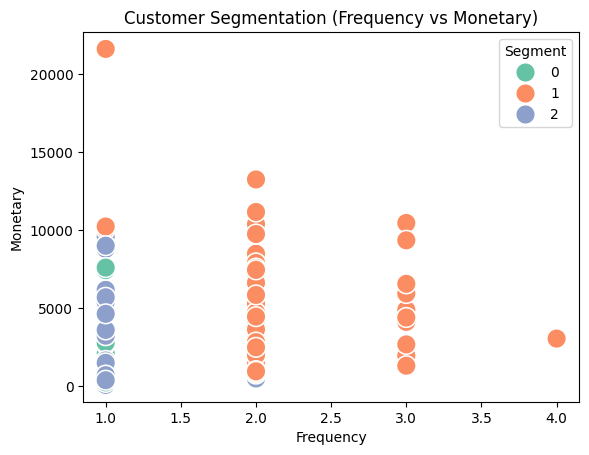

In [71]:
rfm = df.groupby('nama').agg({
    'order_date': 'max',  # Recency
    'total': 'sum',       # Monetary
    'nama': 'count'       # Frequency
}).rename(columns={'order_date':'Recency','total':'Monetary','nama':'Frequency'})

rfm['Recency'] = (pd.Timestamp('today') - rfm['Recency']).dt.days

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Segment'] = kmeans.fit_predict(rfm_scaled)

print("RFM + Segment Data:")
print(rfm)

print("\nMean values per segment:")
print(rfm.groupby('Segment').mean())

sns.scatterplot(
    x='Frequency', 
    y='Monetary', 
    hue='Segment', 
    data=rfm, 
    palette='Set2', 
    s=200
)
plt.title('Customer Segmentation (Frequency vs Monetary)')
plt.show()